_Connecting to .venv (3.12.0) (Python 3.12.0)..._

 # Fase 1 — Análise Exploratória de Dados
 **TechChallenger3 — Previsão de Atrasos de Voos (EUA)**

 Dataset: 5,8 milhões de registros de voos nos EUA (2015)
 Objetivo: entender distribuições, missing values e principais padrões de atraso

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

_ROOT = Path(__file__).resolve().parent.parent
DADOS = _ROOT / "dados"
FIGS  = _ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})
sns.set_theme(style="whitegrid", palette="muted")

DOW_LABELS   = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
MONTH_LABELS = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
DELAY_COLS   = ["AIR_SYSTEM_DELAY","SECURITY_DELAY","AIRLINE_DELAY","LATE_AIRCRAFT_DELAY","WEATHER_DELAY"]

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


 ---
 ## Seção 1 — Carregamento e Inspeção Inicial

In [ ]:
dtype_flights = {
    "YEAR": "int16", "MONTH": "int8", "DAY": "int8", "DAY_OF_WEEK": "int8",
    "AIRLINE": "category", "FLIGHT_NUMBER": "int16",
    "TAIL_NUMBER": "category", "ORIGIN_AIRPORT": "category",
    "DESTINATION_AIRPORT": "category", "SCHEDULED_DEPARTURE": "int32",
    "DEPARTURE_TIME": "float32", "DEPARTURE_DELAY": "float32",
    "TAXI_OUT": "float32", "WHEELS_OFF": "float32", "SCHEDULED_TIME": "float32",
    "ELAPSED_TIME": "float32", "AIR_TIME": "float32", "DISTANCE": "float32",
    "WHEELS_ON": "float32", "TAXI_IN": "float32", "SCHEDULED_ARRIVAL": "int32",
    "ARRIVAL_TIME": "float32", "ARRIVAL_DELAY": "float32",
    "DIVERTED": "int8", "CANCELLED": "int8", "CANCELLATION_REASON": "category",
    "AIR_SYSTEM_DELAY": "float32", "SECURITY_DELAY": "float32",
    "AIRLINE_DELAY": "float32", "LATE_AIRCRAFT_DELAY": "float32",
    "WEATHER_DELAY": "float32",
}

flights  = pd.read_csv(DADOS / "flights.csv",  dtype=dtype_flights, low_memory=False)
airports = pd.read_csv(DADOS / "airports.csv")
airlines = pd.read_csv(DADOS / "airlines.csv")

airline_map  = airlines.set_index("IATA_CODE")["AIRLINE"].to_dict()
airport_map  = airports.set_index("IATA_CODE")["AIRPORT"].to_dict()

mem_mb = flights.memory_usage(deep=True).sum() / 1024**2
print(f"flights  : {flights.shape}  — {mem_mb:.1f} MB")
print(f"airports : {airports.shape}")
print(f"airlines : {airlines.shape}")

flights["AIRLINE_NAME"] = flights["AIRLINE"].astype(str).map(airline_map)

print("\n=== dtypes ===")
print(flights.dtypes.value_counts())

flights  : (5819079, 31)  — 516.6 MB
airports : (322, 7)
airlines : (14, 2)

=== dtypes ===
float32     17
int8         5
int16        2
int32        2
category     1
category     1
category     1
category     1
category     1
str          1
Name: count, dtype: int64


 ---
 ## Seção 2 — Qualidade dos Dados

In [ ]:
print("=== describe — colunas numéricas ===")
print(flights.describe().T.to_string())

=== describe — colunas numéricas ===
                         count         mean          std     min     25%     50%     75%     max
YEAR                 5819079.0  2015.000000     0.000000  2015.0  2015.0  2015.0  2015.0  2015.0
MONTH                5819079.0     6.524085     3.405137     1.0     4.0     7.0     9.0    12.0
DAY                  5819079.0    15.704594     8.783425     1.0     8.0    16.0    23.0    31.0
DAY_OF_WEEK          5819079.0     3.926941     1.988845     1.0     2.0     4.0     6.0     7.0
FLIGHT_NUMBER        5819079.0  2173.092742  1757.063999     1.0   730.0  1690.0  3230.0  9855.0
SCHEDULED_DEPARTURE  5819079.0  1329.602470   483.751821     1.0   917.0  1325.0  1730.0  2359.0
DEPARTURE_TIME       5732926.0  1335.204468   496.423248     1.0   921.0  1330.0  1740.0  2400.0
DEPARTURE_DELAY      5732926.0     9.370158    37.080944   -82.0    -5.0    -2.0     7.0  1988.0
TAXI_OUT             5730032.0    16.071661     8.895575     1.0    11.0    14.0    19.0  

In [ ]:
print("=== valores únicos — colunas categóricas ===")
for col in ["AIRLINE","ORIGIN_AIRPORT","DESTINATION_AIRPORT","CANCELLATION_REASON","TAIL_NUMBER"]:
    print(f"  {col}: {flights[col].nunique()} únicos")

=== valores únicos — colunas categóricas ===
  AIRLINE: 14 únicos
  ORIGIN_AIRPORT: 628 únicos
  DESTINATION_AIRPORT: 629 únicos
  CANCELLATION_REASON: 4 únicos
  TAIL_NUMBER: 4897 únicos


                     total_missing    pct
CANCELLATION_REASON        5729195  98.46
WEATHER_DELAY              4755640  81.72
LATE_AIRCRAFT_DELAY        4755640  81.72
AIRLINE_DELAY              4755640  81.72
SECURITY_DELAY             4755640  81.72
AIR_SYSTEM_DELAY           4755640  81.72
ELAPSED_TIME                105071   1.81
AIR_TIME                    105071   1.81
ARRIVAL_DELAY               105071   1.81
ARRIVAL_TIME                 92513   1.59
TAXI_IN                      92513   1.59
WHEELS_ON                    92513   1.59
WHEELS_OFF                   89047   1.53
TAXI_OUT                     89047   1.53
DEPARTURE_TIME               86153   1.48
DEPARTURE_DELAY              86153   1.48
TAIL_NUMBER                  14721   0.25
SCHEDULED_TIME                   6   0.00


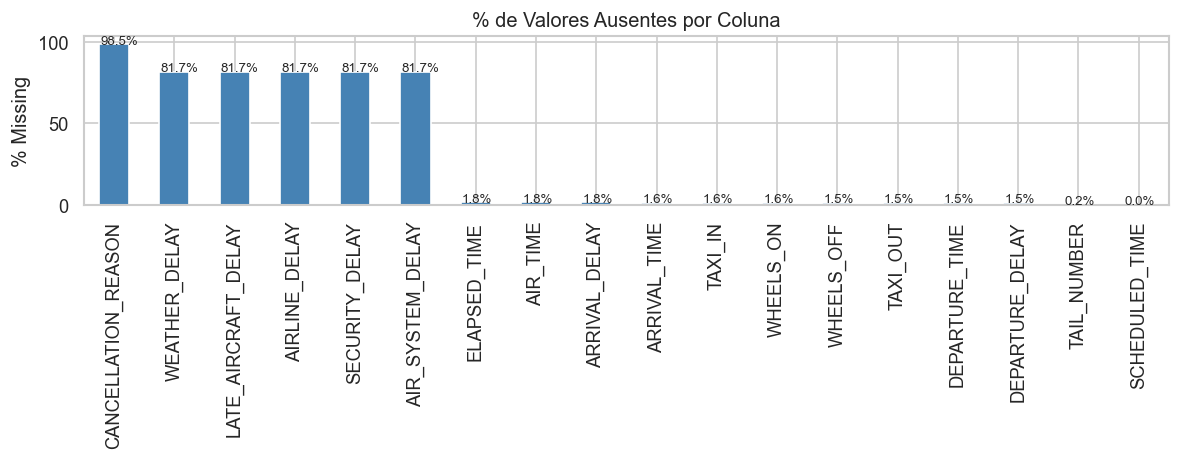

In [ ]:
# Mapa de missing values
missing = (
    flights.isnull().sum()
    .rename("total_missing")
    .to_frame()
    .assign(pct=lambda d: (d["total_missing"] / len(flights) * 100).round(2))
    .query("total_missing > 0")
    .sort_values("total_missing", ascending=False)
)
print(missing.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
missing["pct"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("% de Valores Ausentes por Coluna")
ax.set_ylabel("% Missing")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + 0.02, p.get_height() + 0.3), fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / "eda_01_missing_values.png")
plt.show()

In [ ]:
# Tratamento de missing values
flights[DELAY_COLS] = flights[DELAY_COLS].fillna(0)

# Subsets
flights_cancelled = flights[flights["CANCELLED"] == 1].copy()
flights_ok = flights[(flights["CANCELLED"] == 0) & (flights["DIVERTED"] == 0)].copy()
flights_ok = flights_ok.dropna(subset=["ARRIVAL_DELAY", "DEPARTURE_DELAY"])

print(f"Total voos          : {len(flights):,}")
print(f"Cancelados          : {len(flights_cancelled):,}  ({len(flights_cancelled)/len(flights)*100:.2f}%)")
print(f"Desviados           : {(flights['DIVERTED']==1).sum():,}")
print(f"Voos completados    : {len(flights_ok):,}")

Total voos          : 5,819,079
Cancelados          : 89,884  (1.54%)
Desviados           : 15,187
Voos completados    : 5,714,008


 ---
 ## Seção 3 — Análise da Variável Target

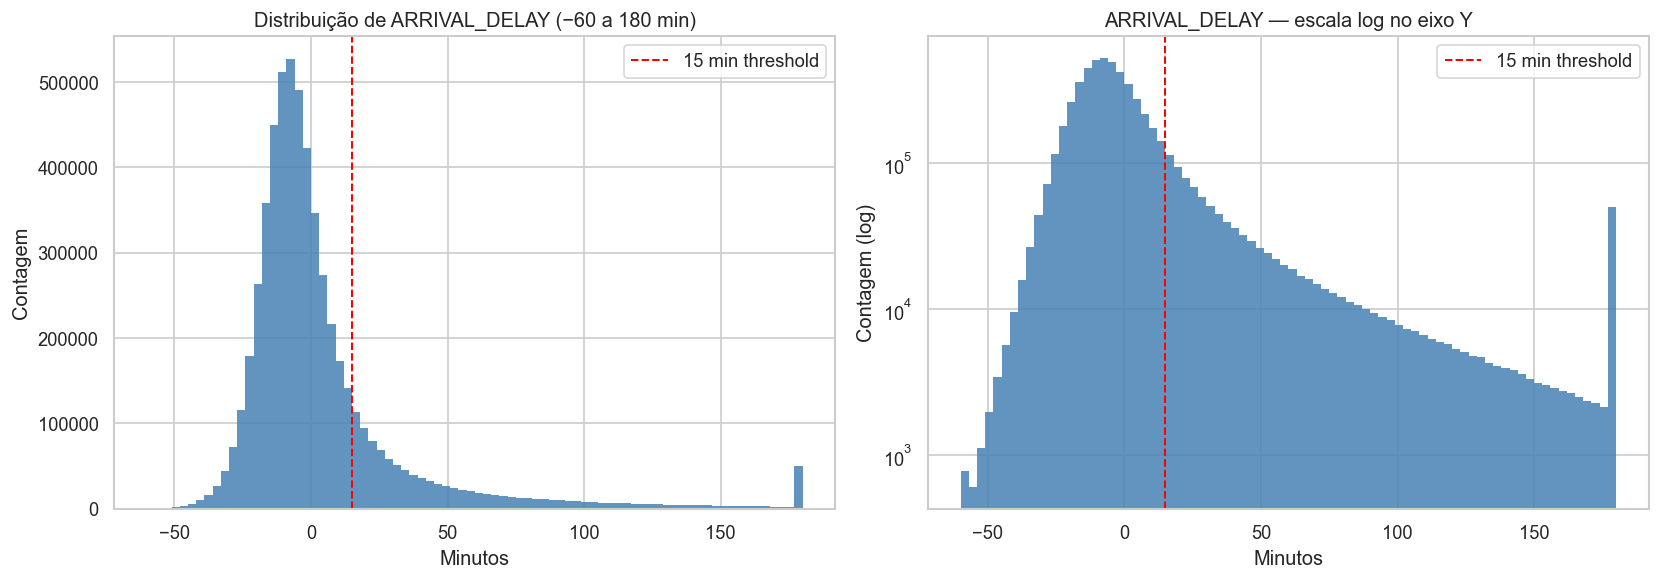

In [ ]:
# Distribuição — linear e log
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clip = flights_ok["ARRIVAL_DELAY"].clip(-60, 180)

axes[0].hist(clip, bins=80, color="steelblue", edgecolor="none", alpha=0.85)
axes[0].axvline(15, color="red", linestyle="--", linewidth=1.2, label="15 min threshold")
axes[0].set_title("Distribuição de ARRIVAL_DELAY (−60 a 180 min)")
axes[0].set_xlabel("Minutos")
axes[0].set_ylabel("Contagem")
axes[0].legend()

axes[1].hist(clip, bins=80, color="steelblue", edgecolor="none", alpha=0.85)
axes[1].set_yscale("log")
axes[1].axvline(15, color="red", linestyle="--", linewidth=1.2, label="15 min threshold")
axes[1].set_title("ARRIVAL_DELAY — escala log no eixo Y")
axes[1].set_xlabel("Minutos")
axes[1].set_ylabel("Contagem (log)")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGS / "eda_02_arrival_delay_dist.png")
plt.show()

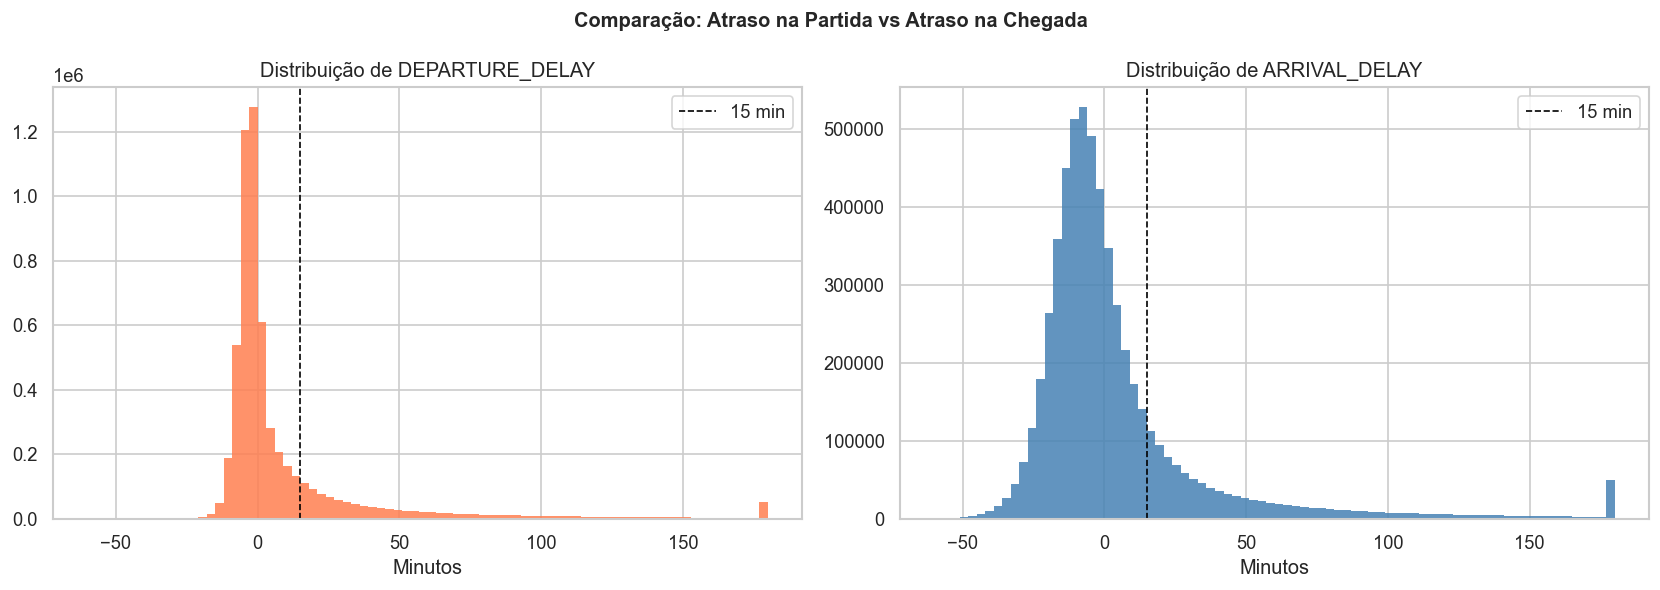

In [ ]:
# DEPARTURE_DELAY vs ARRIVAL_DELAY lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color in zip(axes,
                           ["DEPARTURE_DELAY", "ARRIVAL_DELAY"],
                           ["coral", "steelblue"]):
    ax.hist(flights_ok[col].clip(-60, 180), bins=80, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(15, color="black", linestyle="--", linewidth=1, label="15 min")
    ax.set_title(f"Distribuição de {col}")
    ax.set_xlabel("Minutos")
    ax.legend()
plt.suptitle("Comparação: Atraso na Partida vs Atraso na Chegada", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "eda_03_dep_vs_arr_delay.png")
plt.show()

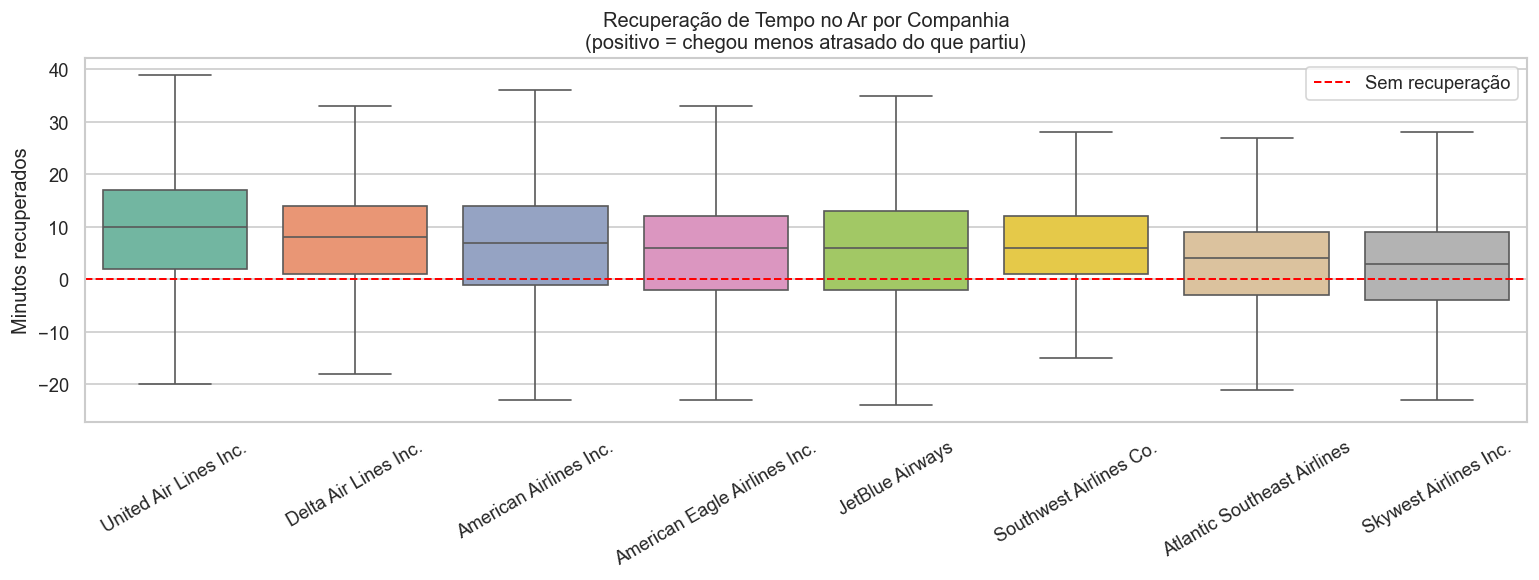

In [ ]:
# Recuperação de tempo no ar — TIME_RECOVERED = DEPARTURE_DELAY - ARRIVAL_DELAY
flights_ok["TIME_RECOVERED"] = flights_ok["DEPARTURE_DELAY"] - flights_ok["ARRIVAL_DELAY"]

top_airline_names = flights_ok["AIRLINE_NAME"].value_counts().head(8).index
df_top = flights_ok[flights_ok["AIRLINE_NAME"].isin(top_airline_names)]
order  = df_top.groupby("AIRLINE_NAME")["TIME_RECOVERED"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df_top, x="AIRLINE_NAME", y="TIME_RECOVERED", order=order,
            showfliers=False, ax=ax, palette="Set2")
ax.axhline(0, color="red", linestyle="--", linewidth=1.2, label="Sem recuperação")
ax.set_title("Recuperação de Tempo no Ar por Companhia\n"
             "(positivo = chegou menos atrasado do que partiu)")
ax.set_xlabel("")
ax.set_ylabel("Minutos recuperados")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / "eda_04_time_recovered.png")
plt.show()

In [ ]:
# Outliers extremos
n_3h = (flights_ok["ARRIVAL_DELAY"] > 180).sum()
n_6h = (flights_ok["ARRIVAL_DELAY"] > 360).sum()
print(f"Voos com atraso > 3h  : {n_3h:,}  ({n_3h/len(flights_ok)*100:.2f}%)")
print(f"Voos com atraso > 6h  : {n_6h:,}  ({n_6h/len(flights_ok)*100:.2f}%)")

print("\n=== Top 10 maiores atrasos ===")
cols_show = ["MONTH","DAY","AIRLINE_NAME","ORIGIN_AIRPORT","DESTINATION_AIRPORT","ARRIVAL_DELAY"]
print(flights_ok.nlargest(10, "ARRIVAL_DELAY")[cols_show].to_string())

Voos com atraso > 3h  : 47,172  (0.83%)
Voos com atraso > 6h  : 6,089  (0.11%)

=== Top 10 maiores atrasos ===
         MONTH  DAY            AIRLINE_NAME ORIGIN_AIRPORT DESTINATION_AIRPORT  ARRIVAL_DELAY
337720       1   23  American Airlines Inc.            BHM                 DFW         1971.0
3412085      8    1  American Airlines Inc.            RIC                 DFW         1898.0
4103531      9   13  American Airlines Inc.            SAN                 DFW         1665.0
5279939     11   27  American Airlines Inc.            DTW                 ORD         1638.0
3100911      7   13  American Airlines Inc.            IND                 LAX         1636.0
5810811     12   31  American Airlines Inc.            ABQ                 DFW         1636.0
886984       2   28  American Airlines Inc.            STL                 MIA         1627.0
1278418      3   24  American Airlines Inc.            OMA                 DFW         1598.0
264495       1   18  American Airlines Inc.

In [ ]:
# Taxa de atraso por threshold
print("Taxa de atraso por threshold:")
for t in [0, 15, 60, 120]:
    rate = (flights_ok["ARRIVAL_DELAY"] > t).mean() * 100
    print(f"  > {t:3d} min : {rate:.1f}%")

Taxa de atraso por threshold:
  >   0 min : 36.5%
  >  15 min : 17.9%
  >  60 min : 5.6%
  > 120 min : 2.0%


 ---
 ## Seção 4 — Análise por Companhia Aérea

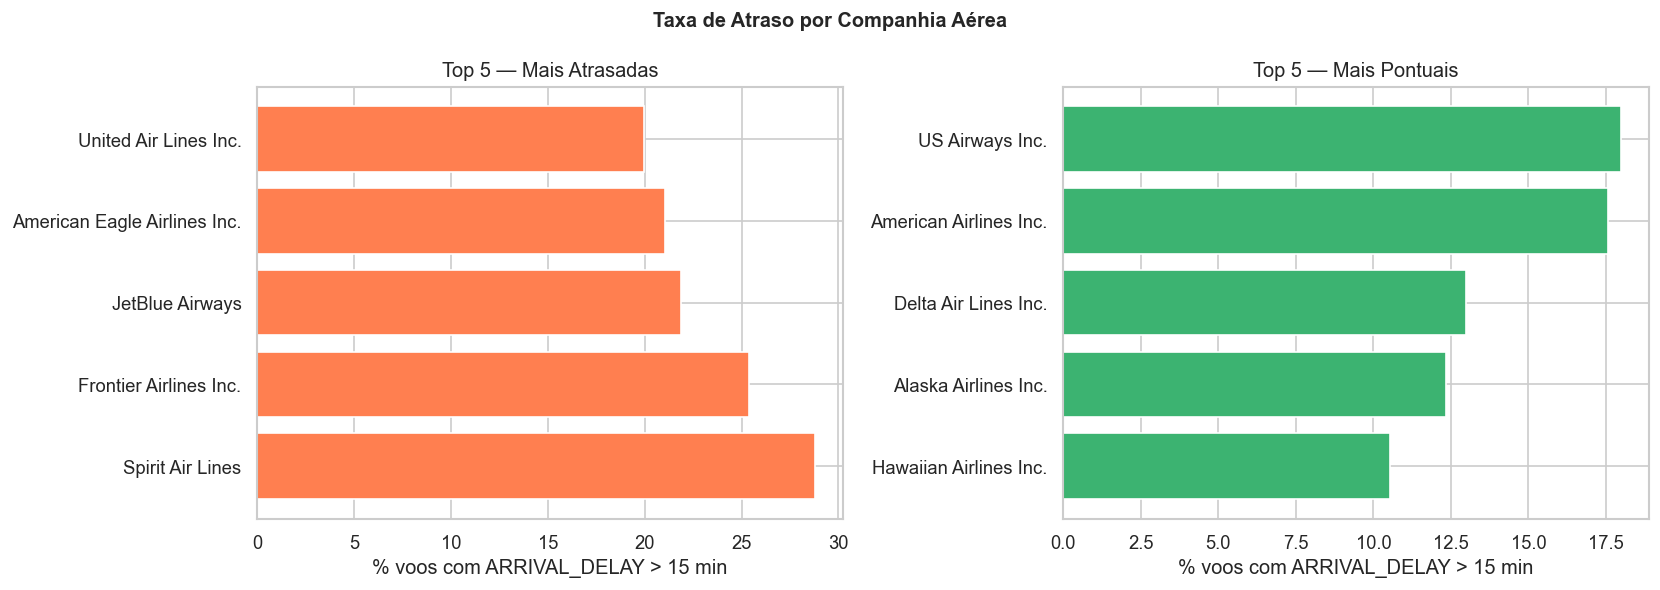

In [ ]:
airline_stats = (
    flights_ok.groupby("AIRLINE_NAME")
    .agg(
        total=("ARRIVAL_DELAY", "count"),
        delay_rate=("ARRIVAL_DELAY", lambda x: (x > 15).mean() * 100),
        avg_arrival_delay=("ARRIVAL_DELAY", "mean"),
        avg_elapsed=("ELAPSED_TIME", "mean"),
        avg_scheduled=("SCHEDULED_TIME", "mean"),
        cancel_rate=("CANCELLED", "mean"),
        diverted_rate=("DIVERTED", "mean"),
    )
    .assign(time_diff=lambda d: d["avg_elapsed"] - d["avg_scheduled"])
    .reset_index()
)

# Top/bottom por taxa de atraso
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, fn, title, color in [
    (axes[0], "nlargest",  "Top 5 — Mais Atrasadas",  "coral"),
    (axes[1], "nsmallest", "Top 5 — Mais Pontuais",   "mediumseagreen"),
]:
    subset = getattr(airline_stats, fn)(5, "delay_rate")
    ax.barh(subset["AIRLINE_NAME"], subset["delay_rate"], color=color)
    ax.set_xlabel("% voos com ARRIVAL_DELAY > 15 min")
    ax.set_title(title)
plt.suptitle("Taxa de Atraso por Companhia Aérea", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "eda_05_airline_delay_rate.png")
plt.show()

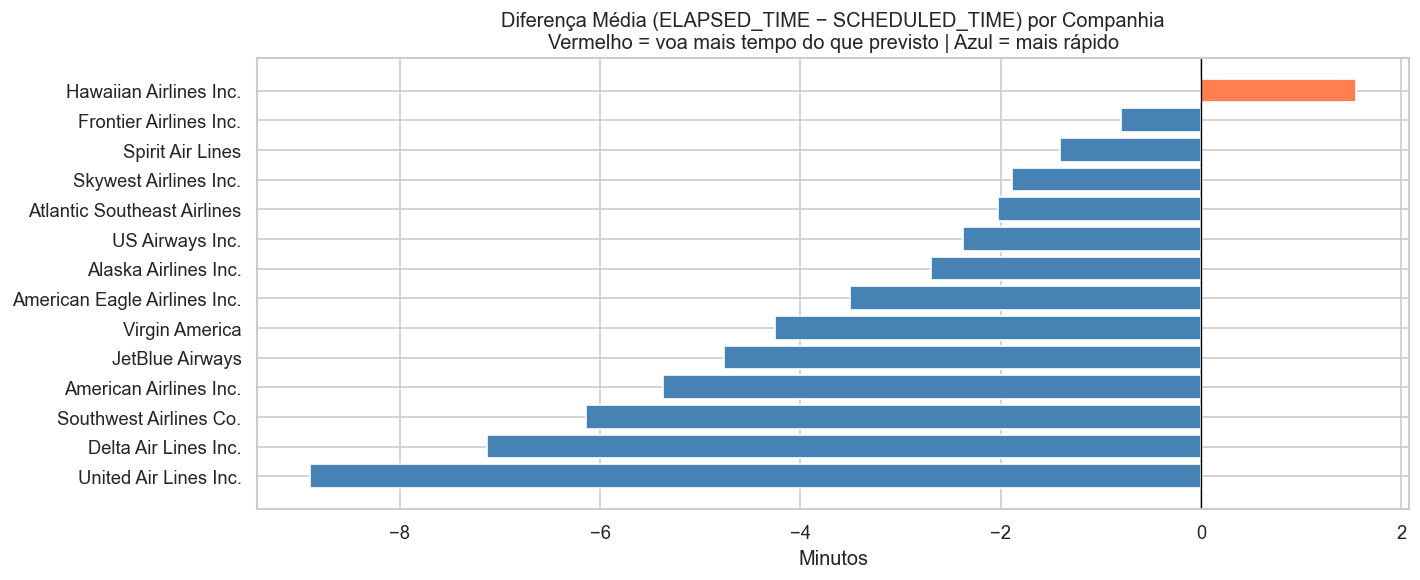

In [ ]:
# Pontualidade operacional: ELAPSED_TIME vs SCHEDULED_TIME
order_time = airline_stats.sort_values("time_diff")["AIRLINE_NAME"]
colors = ["coral" if v > 0 else "steelblue"
          for v in airline_stats.set_index("AIRLINE_NAME").loc[order_time, "time_diff"]]

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(order_time, airline_stats.set_index("AIRLINE_NAME").loc[order_time, "time_diff"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Diferença Média (ELAPSED_TIME − SCHEDULED_TIME) por Companhia\n"
             "Vermelho = voa mais tempo do que previsto | Azul = mais rápido")
ax.set_xlabel("Minutos")
plt.tight_layout()
plt.savefig(FIGS / "eda_06_elapsed_vs_scheduled.png")
plt.show()

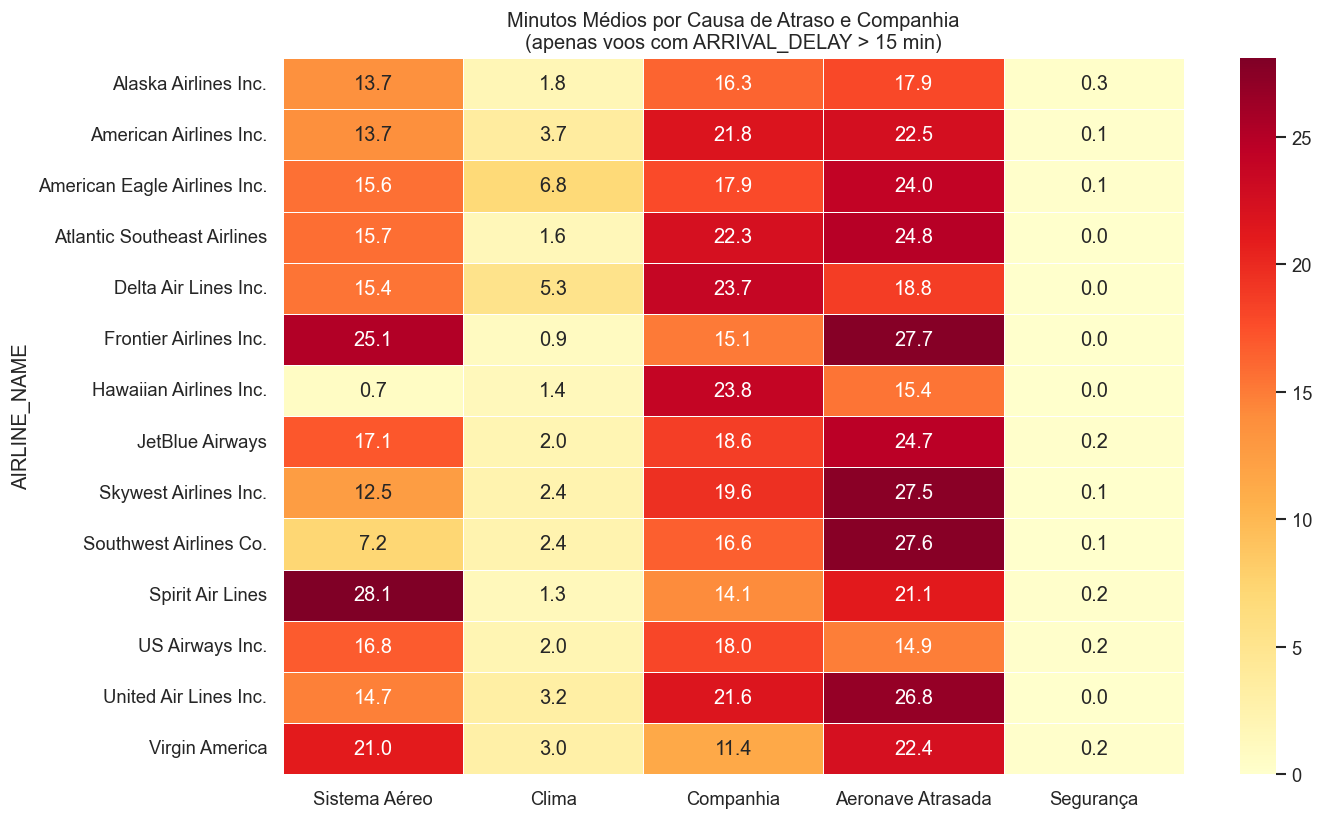

In [ ]:
# Heatmap: causa dominante de atraso por airline
delayed = flights_ok[flights_ok["ARRIVAL_DELAY"] > 15]
cause_labels = {
    "AIR_SYSTEM_DELAY": "Sistema Aéreo",
    "WEATHER_DELAY":    "Clima",
    "AIRLINE_DELAY":    "Companhia",
    "LATE_AIRCRAFT_DELAY": "Aeronave Atrasada",
    "SECURITY_DELAY":   "Segurança",
}
heatmap_df = (
    delayed.groupby("AIRLINE_NAME")[list(cause_labels.keys())].mean()
    .rename(columns=cause_labels)
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax)
ax.set_title("Minutos Médios por Causa de Atraso e Companhia\n(apenas voos com ARRIVAL_DELAY > 15 min)")
plt.tight_layout()
plt.savefig(FIGS / "eda_07_delay_cause_heatmap.png")
plt.show()

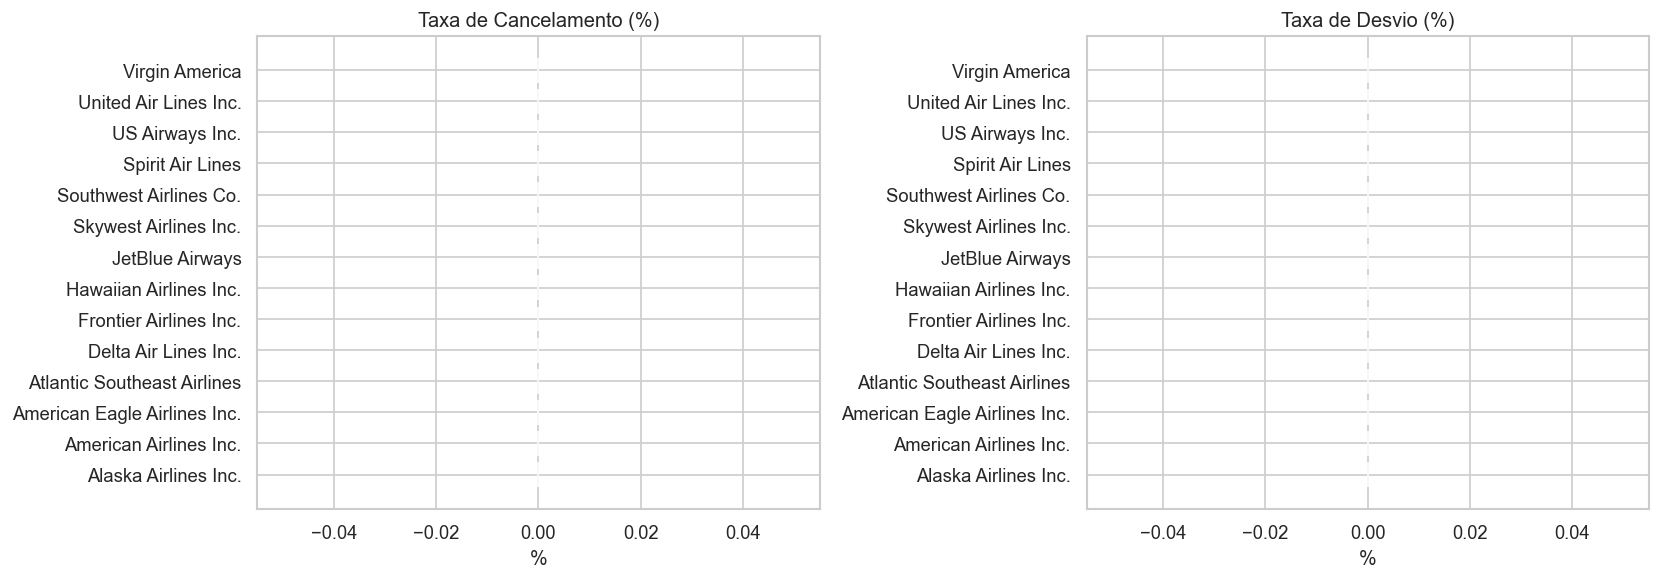

In [ ]:
# Cancelamento e desvio por companhia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, color in [
    (axes[0], "cancel_rate",   "Taxa de Cancelamento (%)", "tomato"),
    (axes[1], "diverted_rate", "Taxa de Desvio (%)",       "mediumpurple"),
]:
    data = airline_stats.sort_values(col, ascending=True)
    ax.barh(data["AIRLINE_NAME"], data[col] * 100, color=color)
    ax.set_xlabel("%")
    ax.set_title(title)
plt.tight_layout()
plt.savefig(FIGS / "eda_08_cancel_diverted.png")
plt.show()

 ---
 ## Seção 5 — Análise Temporal

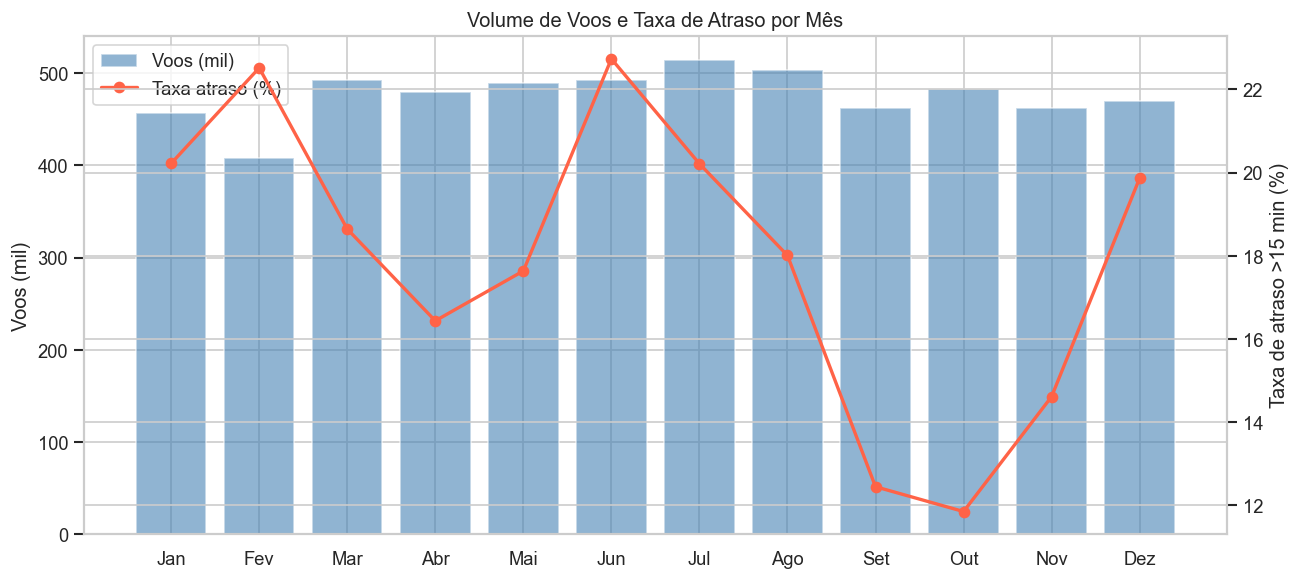

In [ ]:
# Volume e taxa de atraso por mês
monthly = (
    flights_ok.groupby("MONTH")
    .agg(total=("ARRIVAL_DELAY","count"),
         delayed=("ARRIVAL_DELAY", lambda x: (x > 15).sum()))
    .assign(delay_rate=lambda d: d["delayed"] / d["total"] * 100)
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
ax1.bar(MONTH_LABELS, monthly["total"] / 1e3, color="steelblue", alpha=0.6, label="Voos (mil)")
ax2.plot(MONTH_LABELS, monthly["delay_rate"], color="tomato", marker="o",
         linewidth=2, label="Taxa atraso (%)")
ax1.set_ylabel("Voos (mil)")
ax2.set_ylabel("Taxa de atraso >15 min (%)")
ax1.set_title("Volume de Voos e Taxa de Atraso por Mês")
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc="upper left")
plt.tight_layout()
plt.savefig(FIGS / "eda_09_monthly_delay.png")
plt.show()

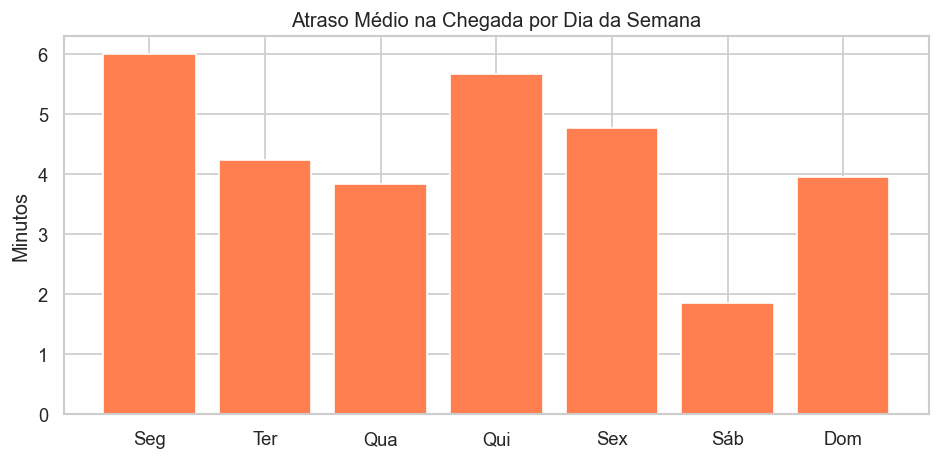

In [ ]:
# Atraso médio por dia da semana
weekly = flights_ok.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(DOW_LABELS, weekly.values, color="coral")
ax.set_title("Atraso Médio na Chegada por Dia da Semana")
ax.set_ylabel("Minutos")
plt.tight_layout()
plt.savefig(FIGS / "eda_10_delay_by_dow.png")
plt.show()

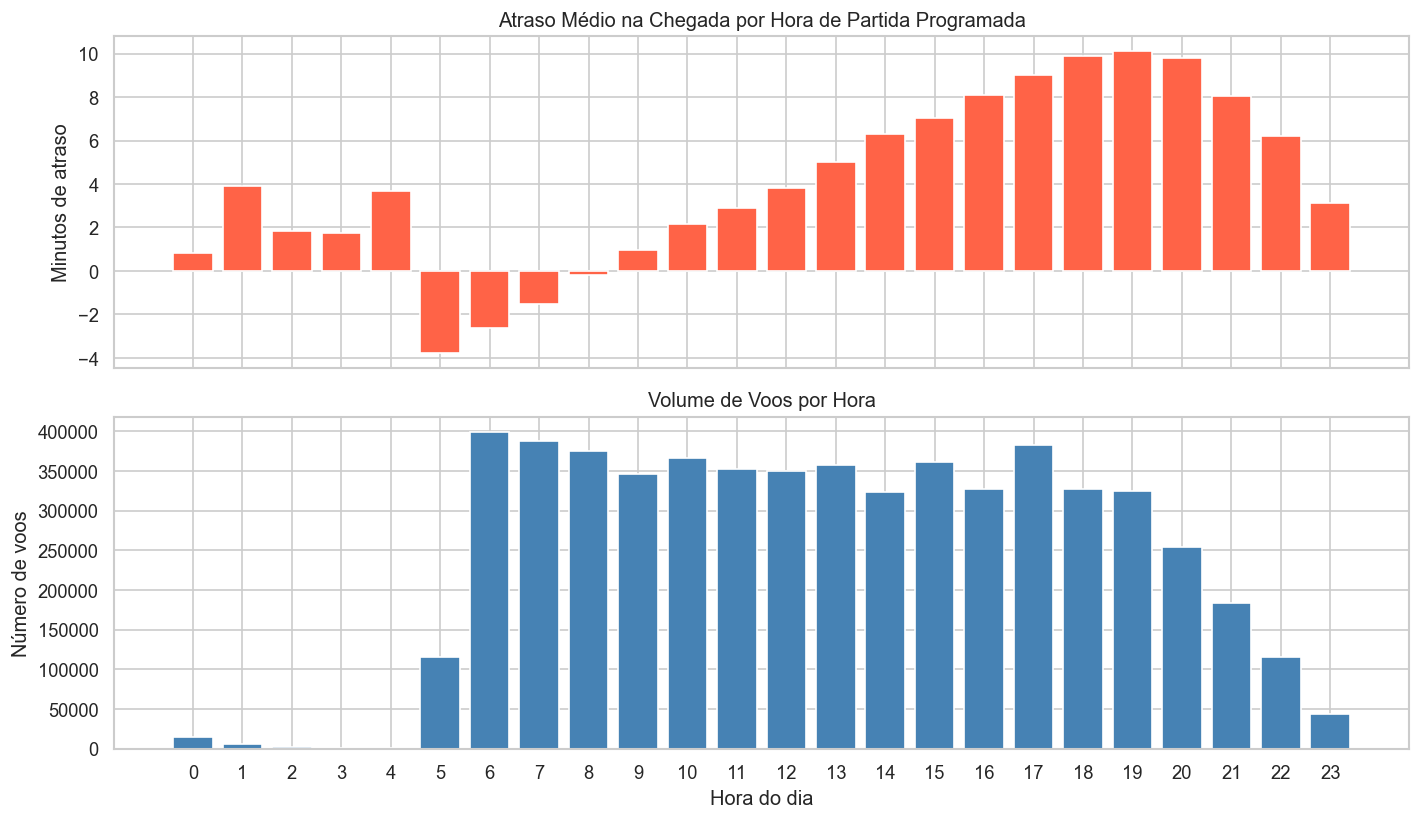

In [ ]:
# Análise por hora do dia (DEPARTURE_HOUR)
flights_ok["DEPARTURE_HOUR"] = (flights_ok["SCHEDULED_DEPARTURE"] // 100).astype("int16")

hourly_delay  = flights_ok.groupby("DEPARTURE_HOUR")["ARRIVAL_DELAY"].mean()
hourly_volume = flights_ok.groupby("DEPARTURE_HOUR").size()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].bar(hourly_delay.index, hourly_delay.values, color="tomato")
axes[0].set_title("Atraso Médio na Chegada por Hora de Partida Programada")
axes[0].set_ylabel("Minutos de atraso")

axes[1].bar(hourly_volume.index, hourly_volume.values, color="steelblue")
axes[1].set_title("Volume de Voos por Hora")
axes[1].set_ylabel("Número de voos")
axes[1].set_xlabel("Hora do dia")
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig(FIGS / "eda_11_delay_by_hour.png")
plt.show()

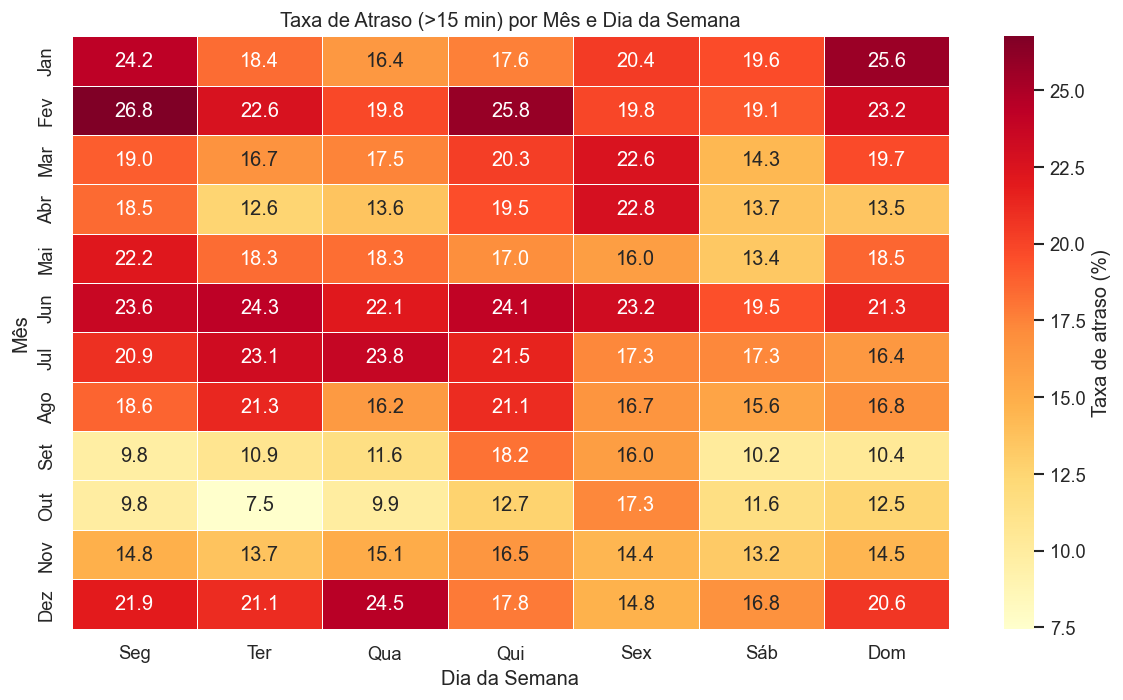

In [ ]:
# Heatmap 2D: DAY_OF_WEEK × MONTH
pivot = (
    flights_ok.assign(delayed=flights_ok["ARRIVAL_DELAY"] > 15)
    .groupby(["MONTH", "DAY_OF_WEEK"])["delayed"]
    .mean()
    .mul(100)
    .unstack("DAY_OF_WEEK")
)
pivot.index   = MONTH_LABELS
pivot.columns = DOW_LABELS

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.4, cbar_kws={"label": "Taxa de atraso (%)"}, ax=ax)
ax.set_title("Taxa de Atraso (>15 min) por Mês e Dia da Semana")
ax.set_xlabel("Dia da Semana")
ax.set_ylabel("Mês")
plt.tight_layout()
plt.savefig(FIGS / "eda_12_heatmap_dow_month.png")
plt.show()

 ---
 ## Seção 6 — Análise por Aeroporto

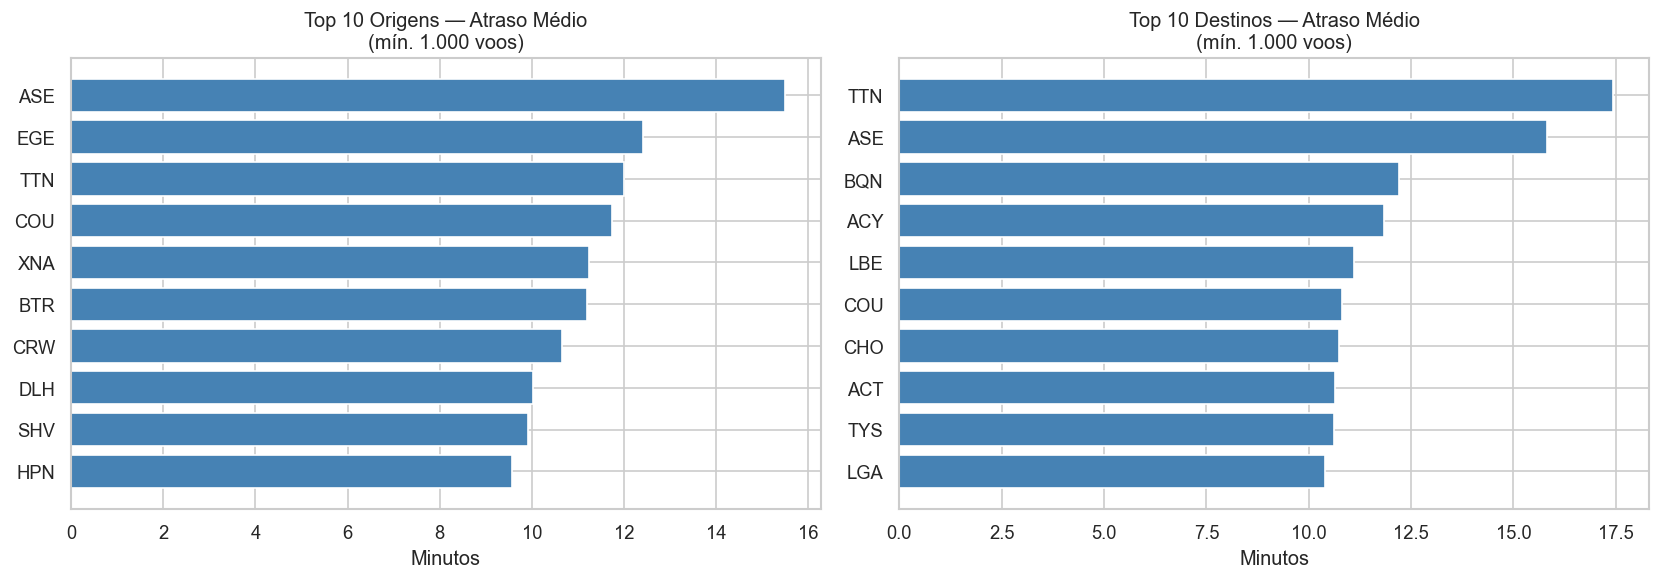

In [ ]:
# Top 10 origens e destinos por atraso médio (mín. 1.000 voos)
def top_airports_by_delay(df, col, n=10, min_flights=1000):
    return (
        df.groupby(col)["ARRIVAL_DELAY"]
        .agg(avg_delay="mean", count="count")
        .query("count >= @min_flights")
        .nlargest(n, "avg_delay")
        .reset_index()
    )

top_orig = top_airports_by_delay(flights_ok, "ORIGIN_AIRPORT")
top_dest = top_airports_by_delay(flights_ok, "DESTINATION_AIRPORT")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, col, title in [
    (axes[0], top_orig, "ORIGIN_AIRPORT",      "Top 10 Origens — Atraso Médio"),
    (axes[1], top_dest, "DESTINATION_AIRPORT",  "Top 10 Destinos — Atraso Médio"),
]:
    ax.barh(data[col][::-1], data["avg_delay"][::-1], color="steelblue")
    ax.set_title(f"{title}\n(mín. 1.000 voos)")
    ax.set_xlabel("Minutos")
plt.tight_layout()
plt.savefig(FIGS / "eda_13_top_airports_delay.png")
plt.show()

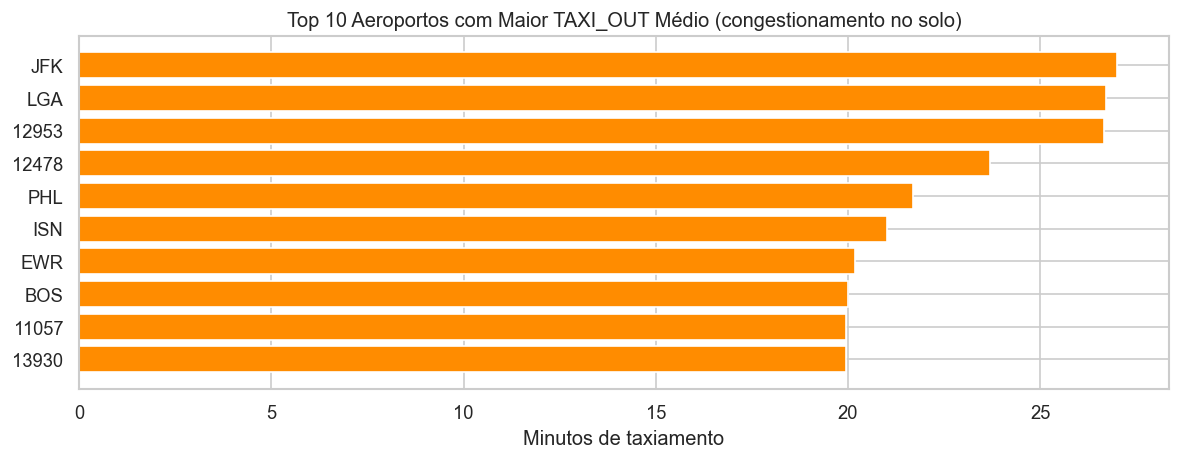

In [ ]:
# Análise de taxiamento: Top 10 aeroportos com maior TAXI_OUT médio
taxi_stats = (
    flights_ok.groupby("ORIGIN_AIRPORT")["TAXI_OUT"]
    .agg(avg_taxi="mean", count="count")
    .query("count >= 1000")
    .nlargest(10, "avg_taxi")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(taxi_stats["ORIGIN_AIRPORT"][::-1], taxi_stats["avg_taxi"][::-1], color="darkorange")
ax.set_title("Top 10 Aeroportos com Maior TAXI_OUT Médio (congestionamento no solo)")
ax.set_xlabel("Minutos de taxiamento")
plt.tight_layout()
plt.savefig(FIGS / "eda_14_top_taxi_out.png")
plt.show()

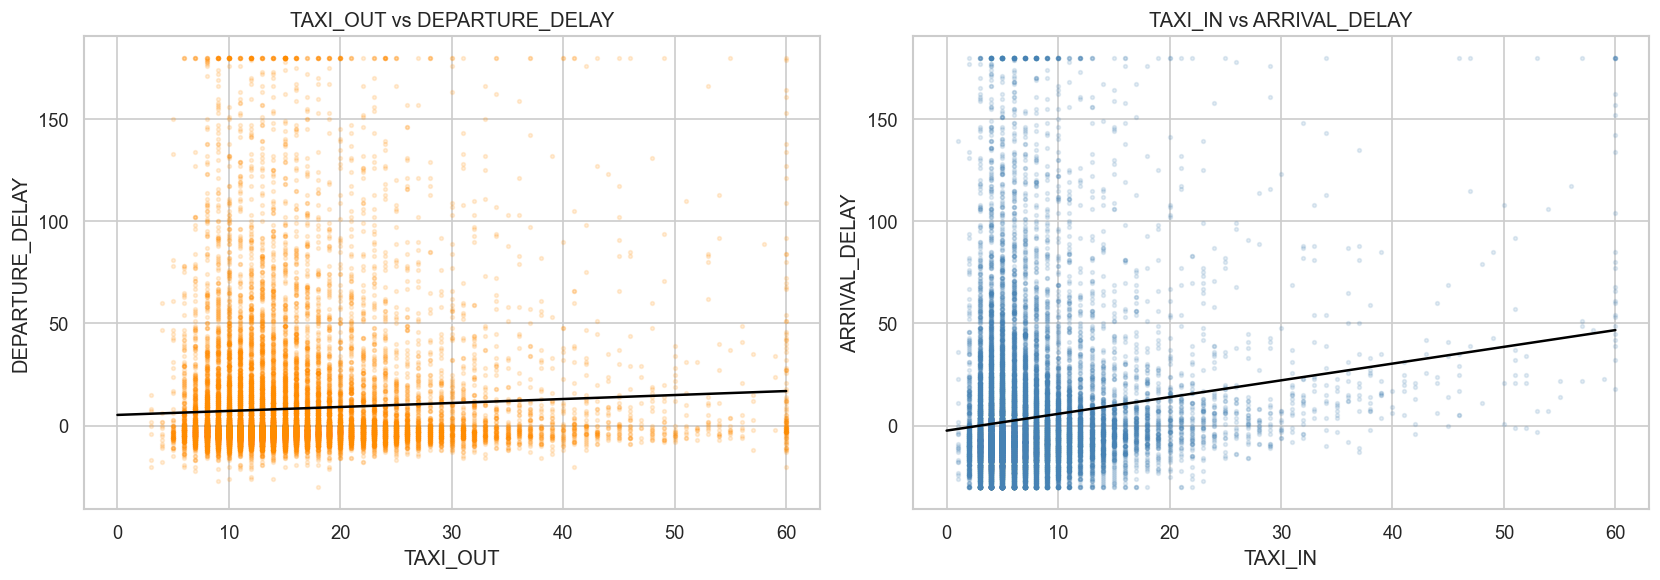

In [ ]:
# Scatter: TAXI_OUT vs DEPARTURE_DELAY e TAXI_IN vs ARRIVAL_DELAY
sample = (
    flights_ok[["TAXI_OUT","DEPARTURE_DELAY","TAXI_IN","ARRIVAL_DELAY"]]
    .dropna()
    .sample(20_000, random_state=42)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, x, y, color in [
    (axes[0], "TAXI_OUT", "DEPARTURE_DELAY", "darkorange"),
    (axes[1], "TAXI_IN",  "ARRIVAL_DELAY",   "steelblue"),
]:
    xc = sample[x].clip(0, 60)
    yc = sample[y].clip(-30, 180)
    ax.scatter(xc, yc, alpha=0.15, s=5, color=color)
    m, b = np.polyfit(xc, yc, 1)
    ax.plot(np.linspace(0, 60, 100), m * np.linspace(0, 60, 100) + b,
            color="black", linewidth=1.5)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")
plt.tight_layout()
plt.savefig(FIGS / "eda_15_taxi_vs_delay.png")
plt.show()

 ---
 ## Seção 7 — Análise de Rotas e Distância

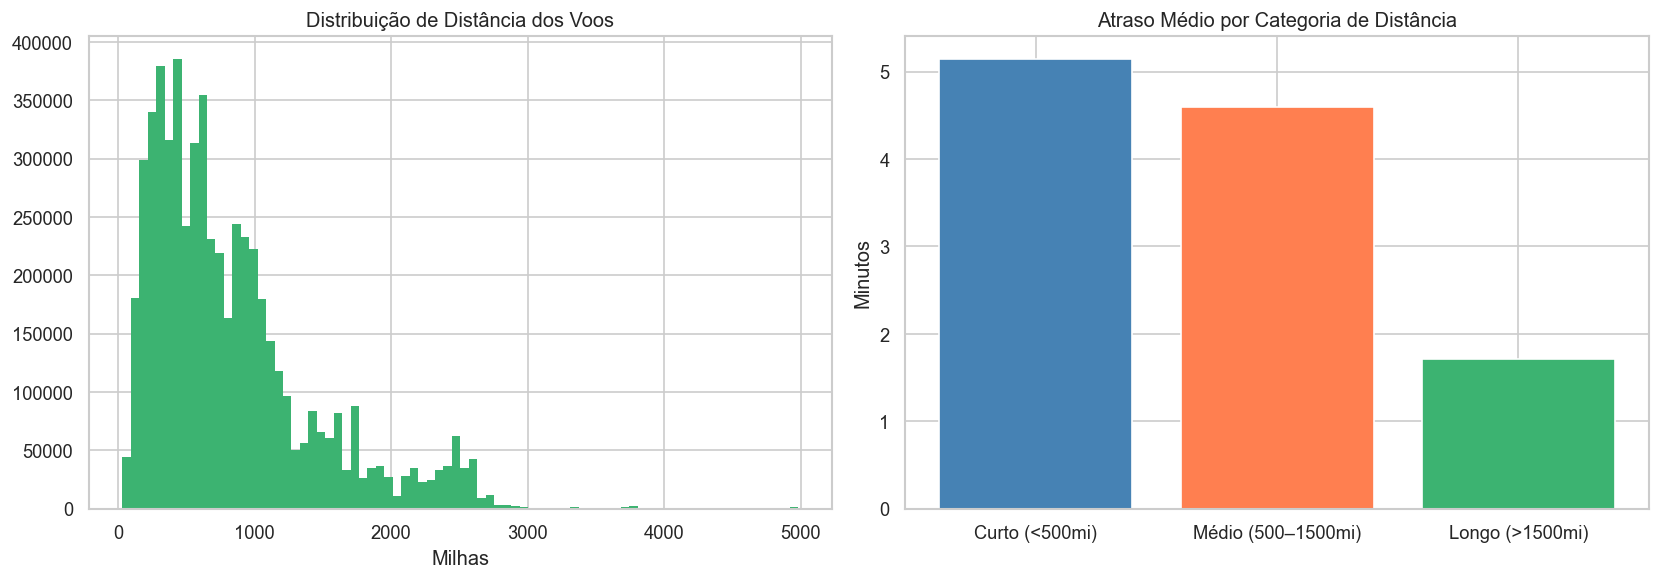

In [ ]:
# Distribuição de DISTANCE e atraso por bucket
flights_ok["DISTANCE_BUCKET"] = pd.cut(
    flights_ok["DISTANCE"],
    bins=[0, 500, 1500, 10_000],
    labels=["Curto (<500mi)", "Médio (500–1500mi)", "Longo (>1500mi)"],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
flights_ok["DISTANCE"].hist(bins=80, ax=axes[0], color="mediumseagreen", edgecolor="none")
axes[0].set_title("Distribuição de Distância dos Voos")
axes[0].set_xlabel("Milhas")

bucket_delay = flights_ok.groupby("DISTANCE_BUCKET", observed=True)["ARRIVAL_DELAY"].mean()
axes[1].bar(bucket_delay.index, bucket_delay.values,
            color=["steelblue", "coral", "mediumseagreen"])
axes[1].set_title("Atraso Médio por Categoria de Distância")
axes[1].set_ylabel("Minutos")

plt.tight_layout()
plt.savefig(FIGS / "eda_16_distance_analysis.png")
plt.show()

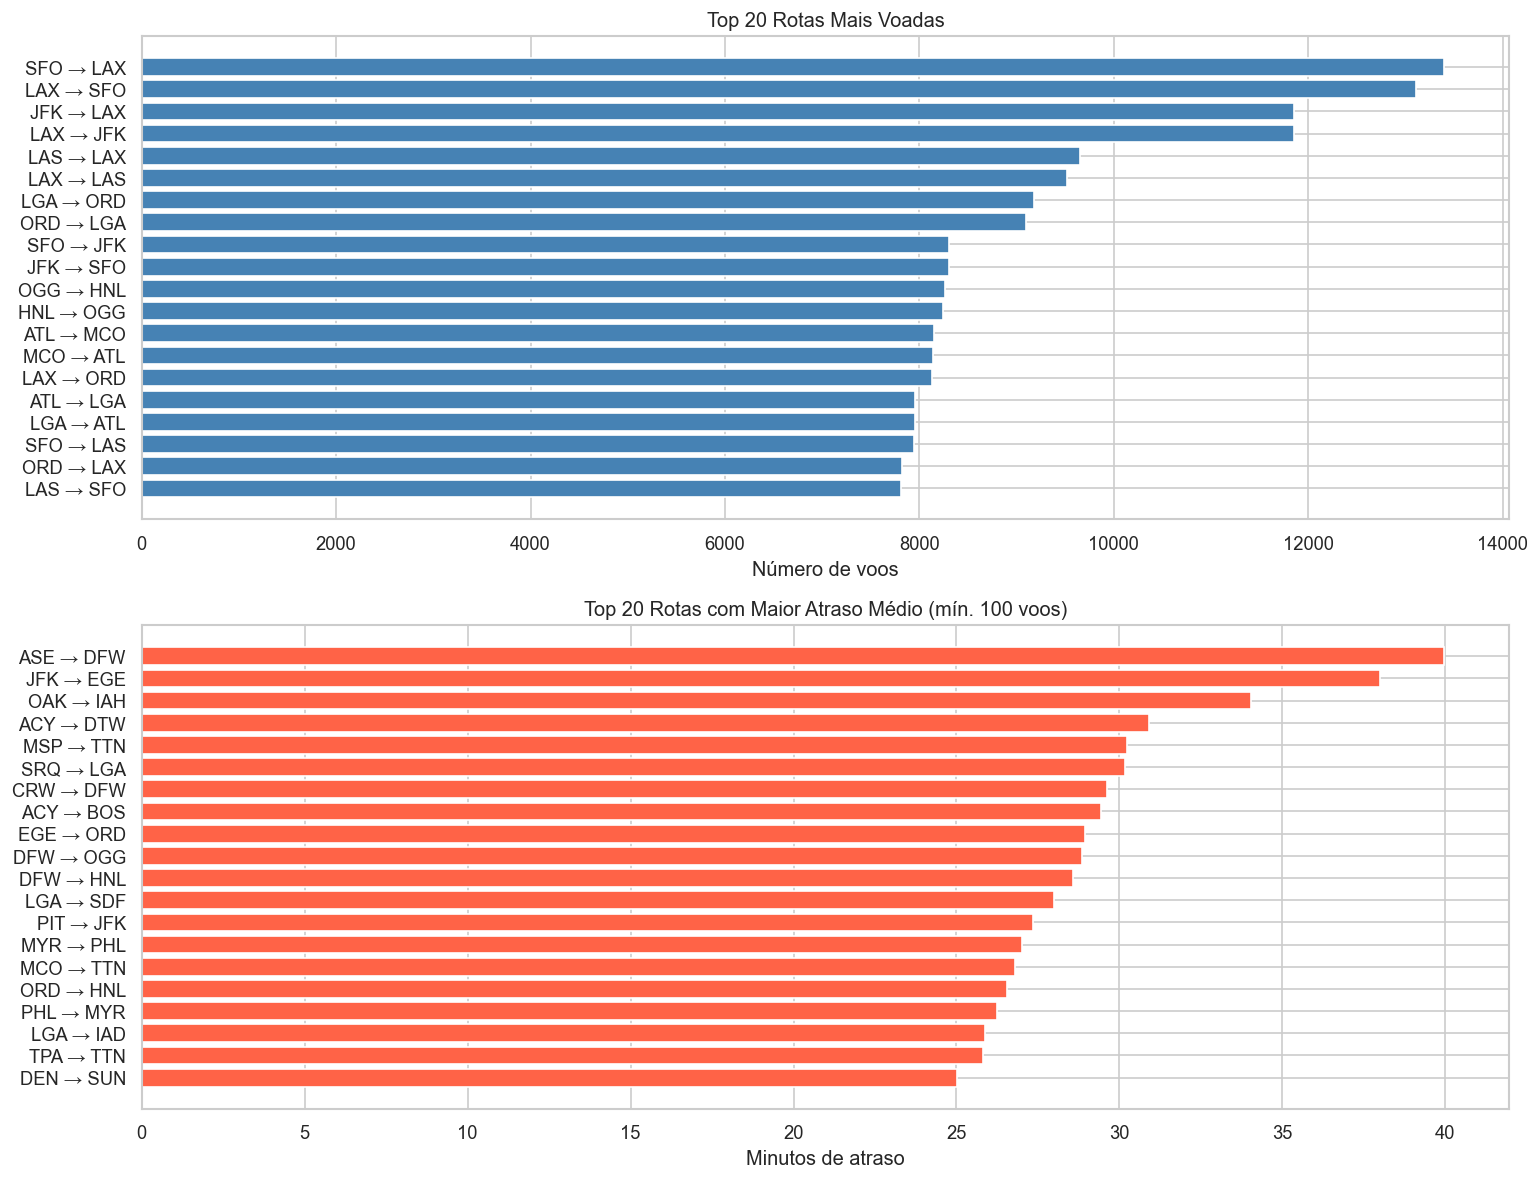

In [ ]:
# Top rotas por volume e por atraso
flights_ok["ROUTE"] = (flights_ok["ORIGIN_AIRPORT"].astype(str)
                       + " → "
                       + flights_ok["DESTINATION_AIRPORT"].astype(str))

top_routes_vol = (
    flights_ok["ROUTE"].value_counts().head(20)
    .reset_index().rename(columns={"count": "FLIGHTS"})
)
top_routes_delay = (
    flights_ok.groupby("ROUTE")
    .agg(avg_delay=("ARRIVAL_DELAY","mean"), count=("ARRIVAL_DELAY","count"))
    .query("count >= 100")
    .nlargest(20, "avg_delay")
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
axes[0].barh(top_routes_vol["ROUTE"][::-1], top_routes_vol["FLIGHTS"][::-1], color="steelblue")
axes[0].set_title("Top 20 Rotas Mais Voadas")
axes[0].set_xlabel("Número de voos")

axes[1].barh(top_routes_delay["ROUTE"][::-1], top_routes_delay["avg_delay"][::-1], color="tomato")
axes[1].set_title("Top 20 Rotas com Maior Atraso Médio (mín. 100 voos)")
axes[1].set_xlabel("Minutos de atraso")

plt.tight_layout()
plt.savefig(FIGS / "eda_17_top_routes.png")
plt.show()

 ---
 ## Seção 8 — Cancelamentos e Desvios

In [ ]:
n_total    = len(flights)
n_cancel   = (flights["CANCELLED"] == 1).sum()
n_diverted = (flights["DIVERTED"] == 1).sum()
print(f"Cancelados : {n_cancel:,}  ({n_cancel/n_total*100:.2f}%)")
print(f"Desviados  : {n_diverted:,}  ({n_diverted/n_total*100:.2f}%)")

Cancelados : 89,884  (1.54%)
Desviados  : 15,187  (0.26%)


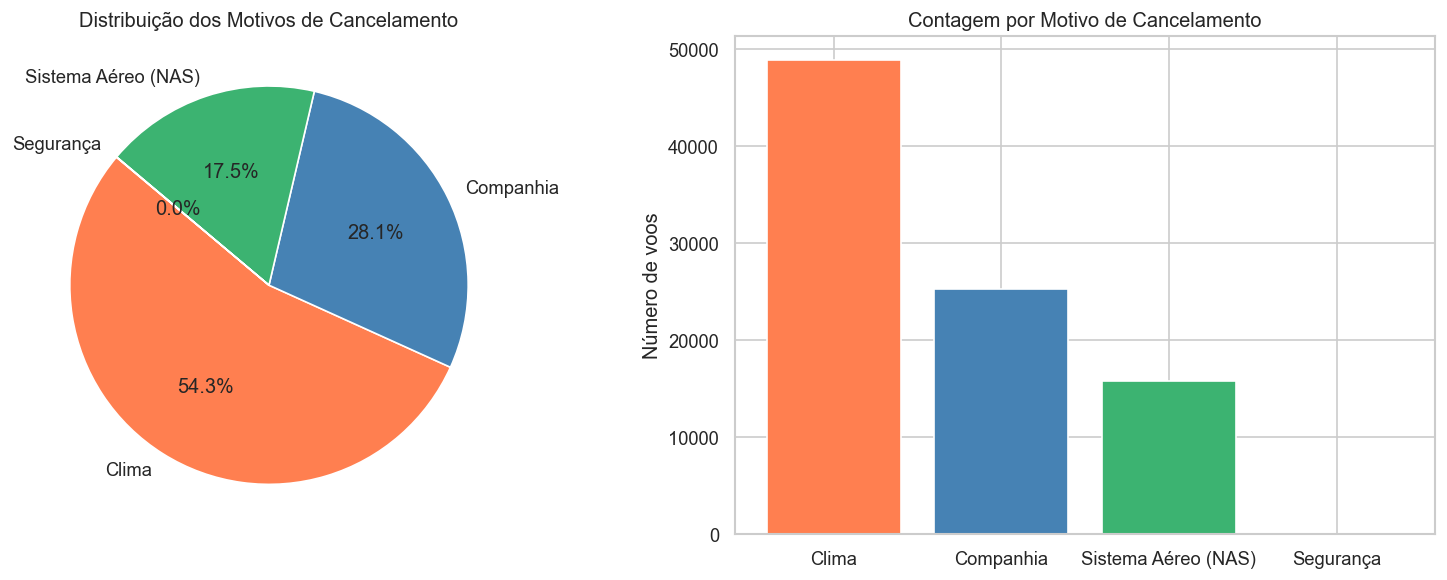

In [ ]:
# Distribuição de CANCELLATION_REASON
reason_map    = {"A": "Companhia", "B": "Clima", "C": "Sistema Aéreo (NAS)", "D": "Segurança"}
reason_counts = flights_cancelled["CANCELLATION_REASON"].map(reason_map).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_pie = ["coral", "steelblue", "mediumseagreen", "gold"]
axes[0].pie(reason_counts.values, labels=reason_counts.index,
            autopct="%1.1f%%", colors=colors_pie, startangle=140)
axes[0].set_title("Distribuição dos Motivos de Cancelamento")

axes[1].bar(reason_counts.index, reason_counts.values, color=colors_pie)
axes[1].set_title("Contagem por Motivo de Cancelamento")
axes[1].set_ylabel("Número de voos")

plt.tight_layout()
plt.savefig(FIGS / "eda_18_cancellation_reason.png")
plt.show()

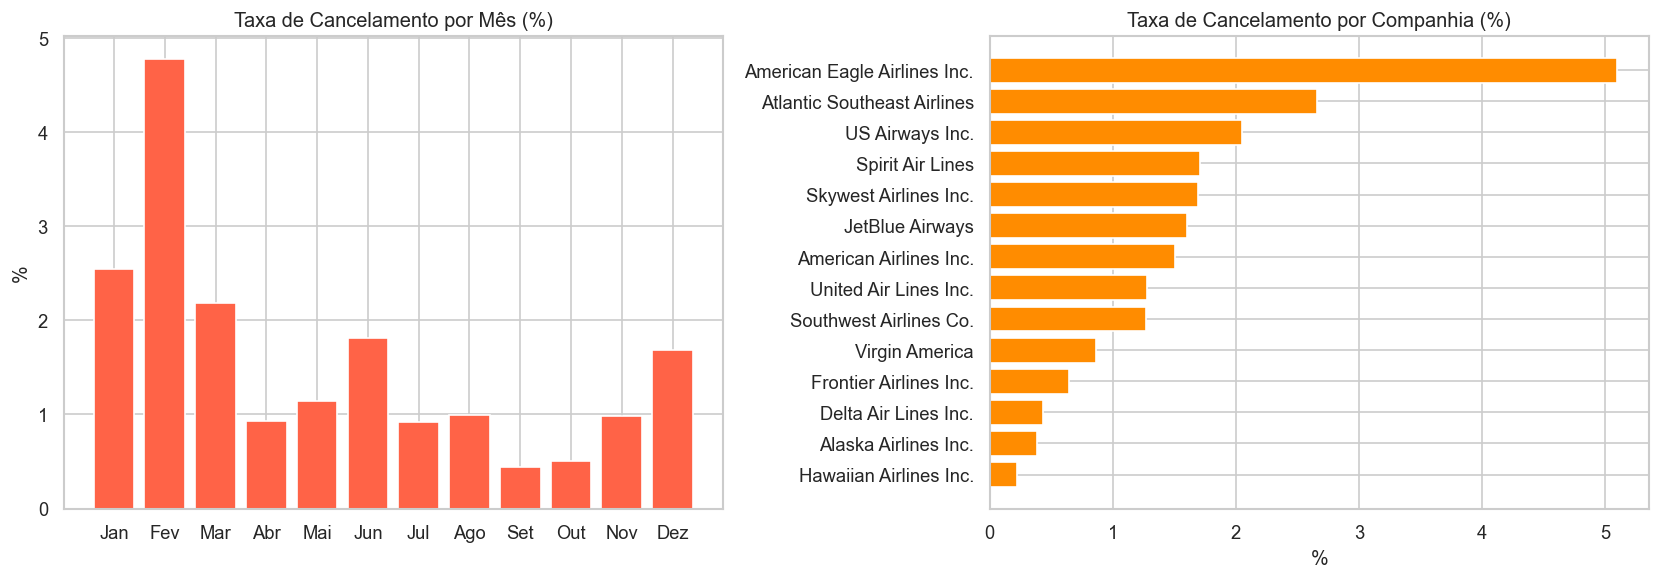

In [ ]:
# Cancelamentos por mês e por companhia
cancel_month = flights.groupby("MONTH")["CANCELLED"].mean() * 100
cancel_airline = (
    flights.groupby("AIRLINE_NAME")["CANCELLED"].mean()
    .sort_values(ascending=True) * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(MONTH_LABELS, cancel_month.values, color="tomato")
axes[0].set_title("Taxa de Cancelamento por Mês (%)")
axes[0].set_ylabel("%")

axes[1].barh(cancel_airline.index, cancel_airline.values, color="darkorange")
axes[1].set_title("Taxa de Cancelamento por Companhia (%)")
axes[1].set_xlabel("%")

plt.tight_layout()
plt.savefig(FIGS / "eda_19_cancellations.png")
plt.show()

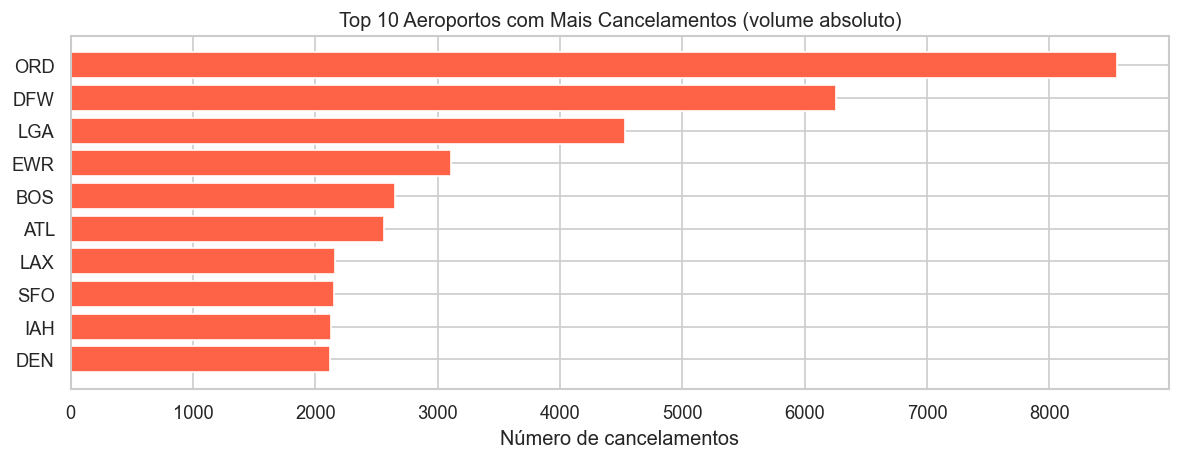

In [ ]:
# Top 10 aeroportos de origem com mais cancelamentos
top_cancel_ap = (
    flights_cancelled["ORIGIN_AIRPORT"].value_counts().head(10)
    .reset_index().rename(columns={"count": "CANCELLED_FLIGHTS"})
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top_cancel_ap["ORIGIN_AIRPORT"][::-1],
        top_cancel_ap["CANCELLED_FLIGHTS"][::-1], color="tomato")
ax.set_title("Top 10 Aeroportos com Mais Cancelamentos (volume absoluto)")
ax.set_xlabel("Número de cancelamentos")
plt.tight_layout()
plt.savefig(FIGS / "eda_20_cancel_by_airport.png")
plt.show()

 ---
 ## Seção 9 — Correlações e Features para Modelagem

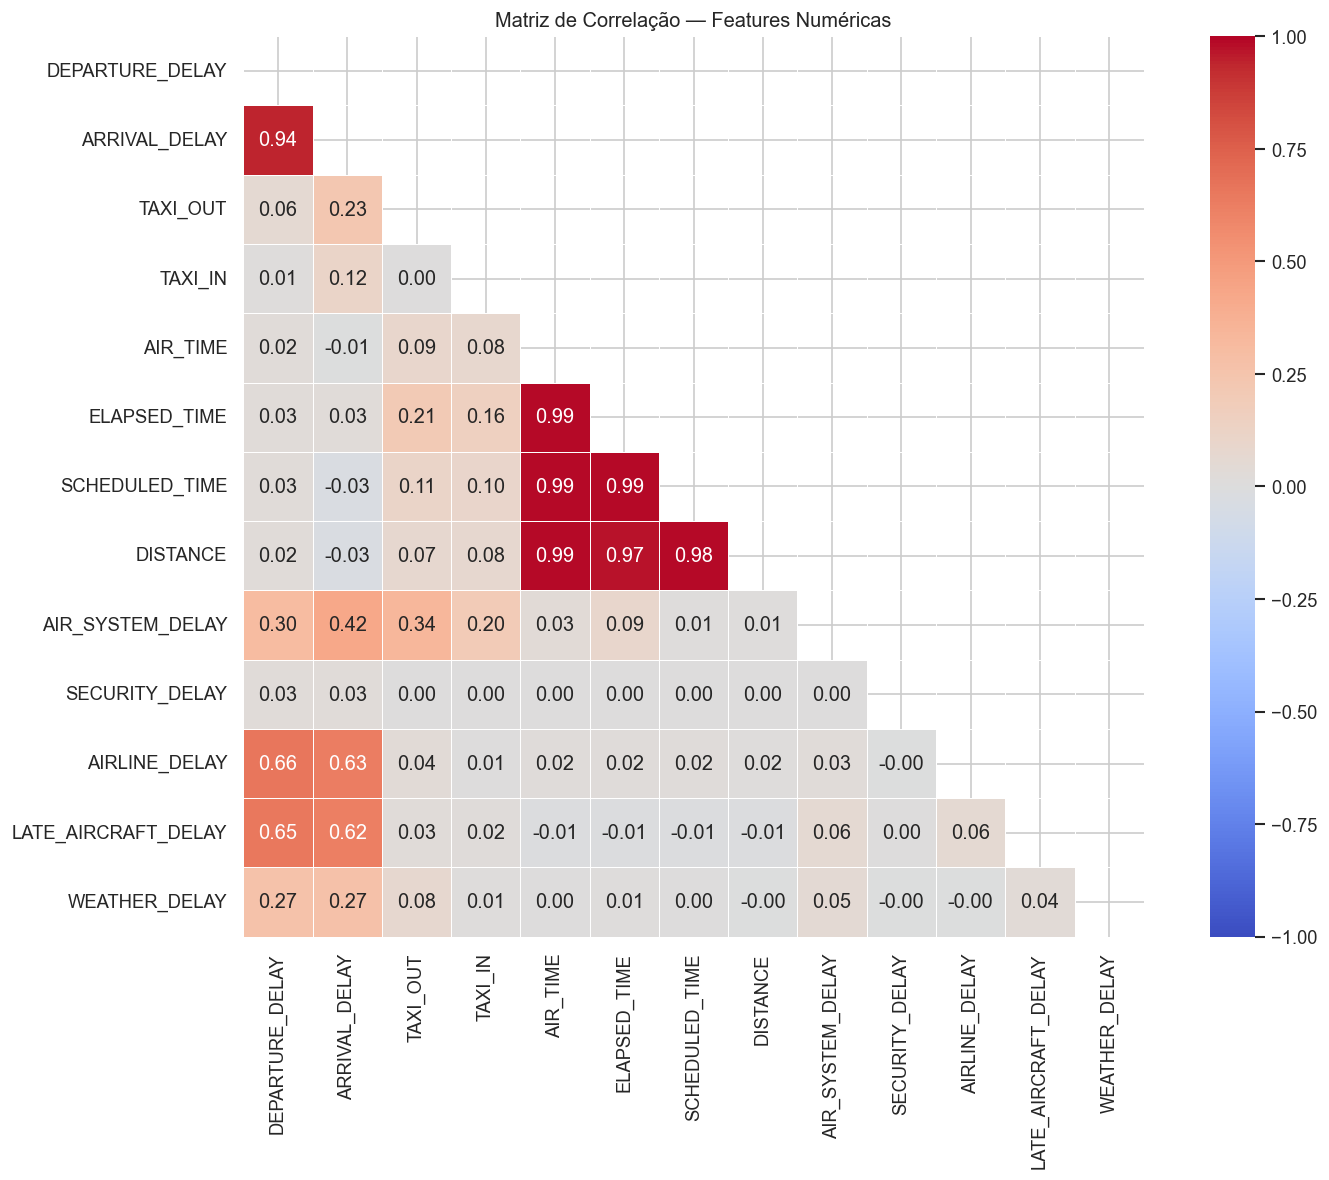

In [ ]:
# Heatmap de correlação completo
num_cols = [
    "DEPARTURE_DELAY","ARRIVAL_DELAY","TAXI_OUT","TAXI_IN",
    "AIR_TIME","ELAPSED_TIME","SCHEDULED_TIME","DISTANCE",
    "AIR_SYSTEM_DELAY","SECURITY_DELAY","AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY","WEATHER_DELAY",
]
corr = flights_ok[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.4, square=True, ax=ax)
ax.set_title("Matriz de Correlação — Features Numéricas")
plt.tight_layout()
plt.savefig(FIGS / "eda_21_correlation_heatmap.png")
plt.show()

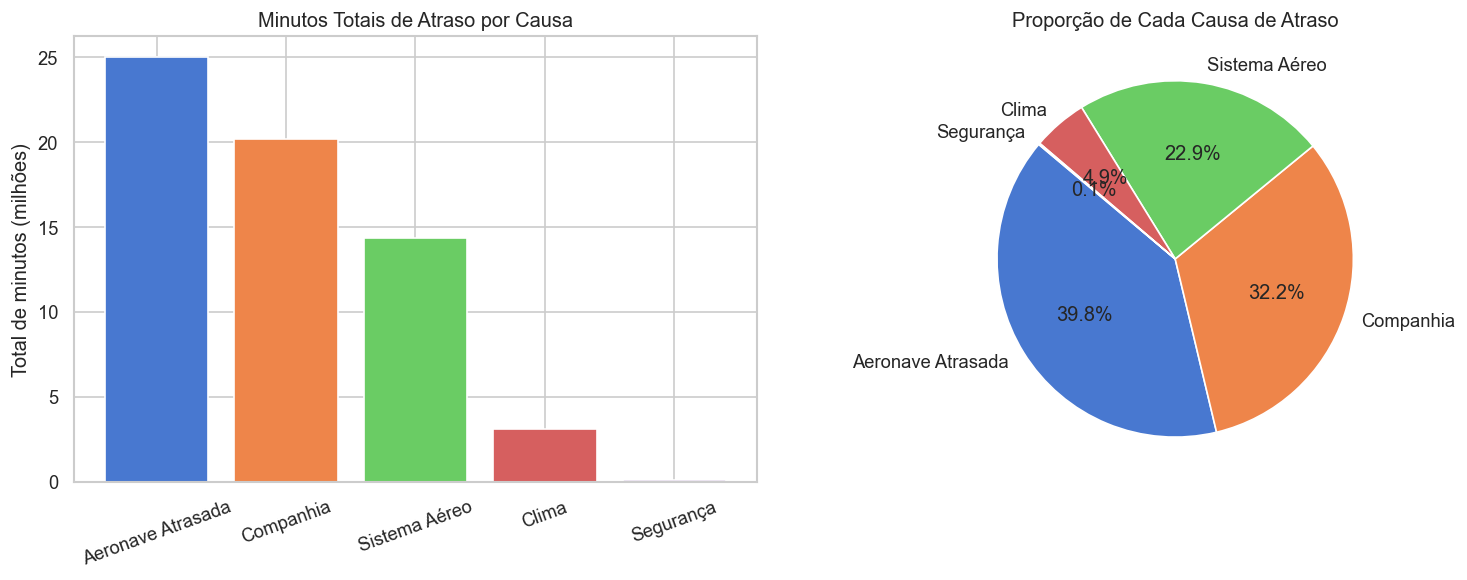

In [ ]:
# Causas de atraso — proporção geral
delay_totals = (
    flights_ok[DELAY_COLS].sum()
    .rename(index={
        "AIR_SYSTEM_DELAY":   "Sistema Aéreo",
        "SECURITY_DELAY":     "Segurança",
        "AIRLINE_DELAY":      "Companhia",
        "LATE_AIRCRAFT_DELAY":"Aeronave Atrasada",
        "WEATHER_DELAY":      "Clima",
    })
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(delay_totals.index, delay_totals.values / 1e6,
            color=sns.color_palette("muted", 5))
axes[0].set_ylabel("Total de minutos (milhões)")
axes[0].set_title("Minutos Totais de Atraso por Causa")
axes[0].tick_params(axis="x", rotation=20)

axes[1].pie(delay_totals.values, labels=delay_totals.index,
            autopct="%1.1f%%", colors=sns.color_palette("muted", 5), startangle=140)
axes[1].set_title("Proporção de Cada Causa de Atraso")

plt.tight_layout()
plt.savefig(FIGS / "eda_22_delay_causes.png")
plt.show()

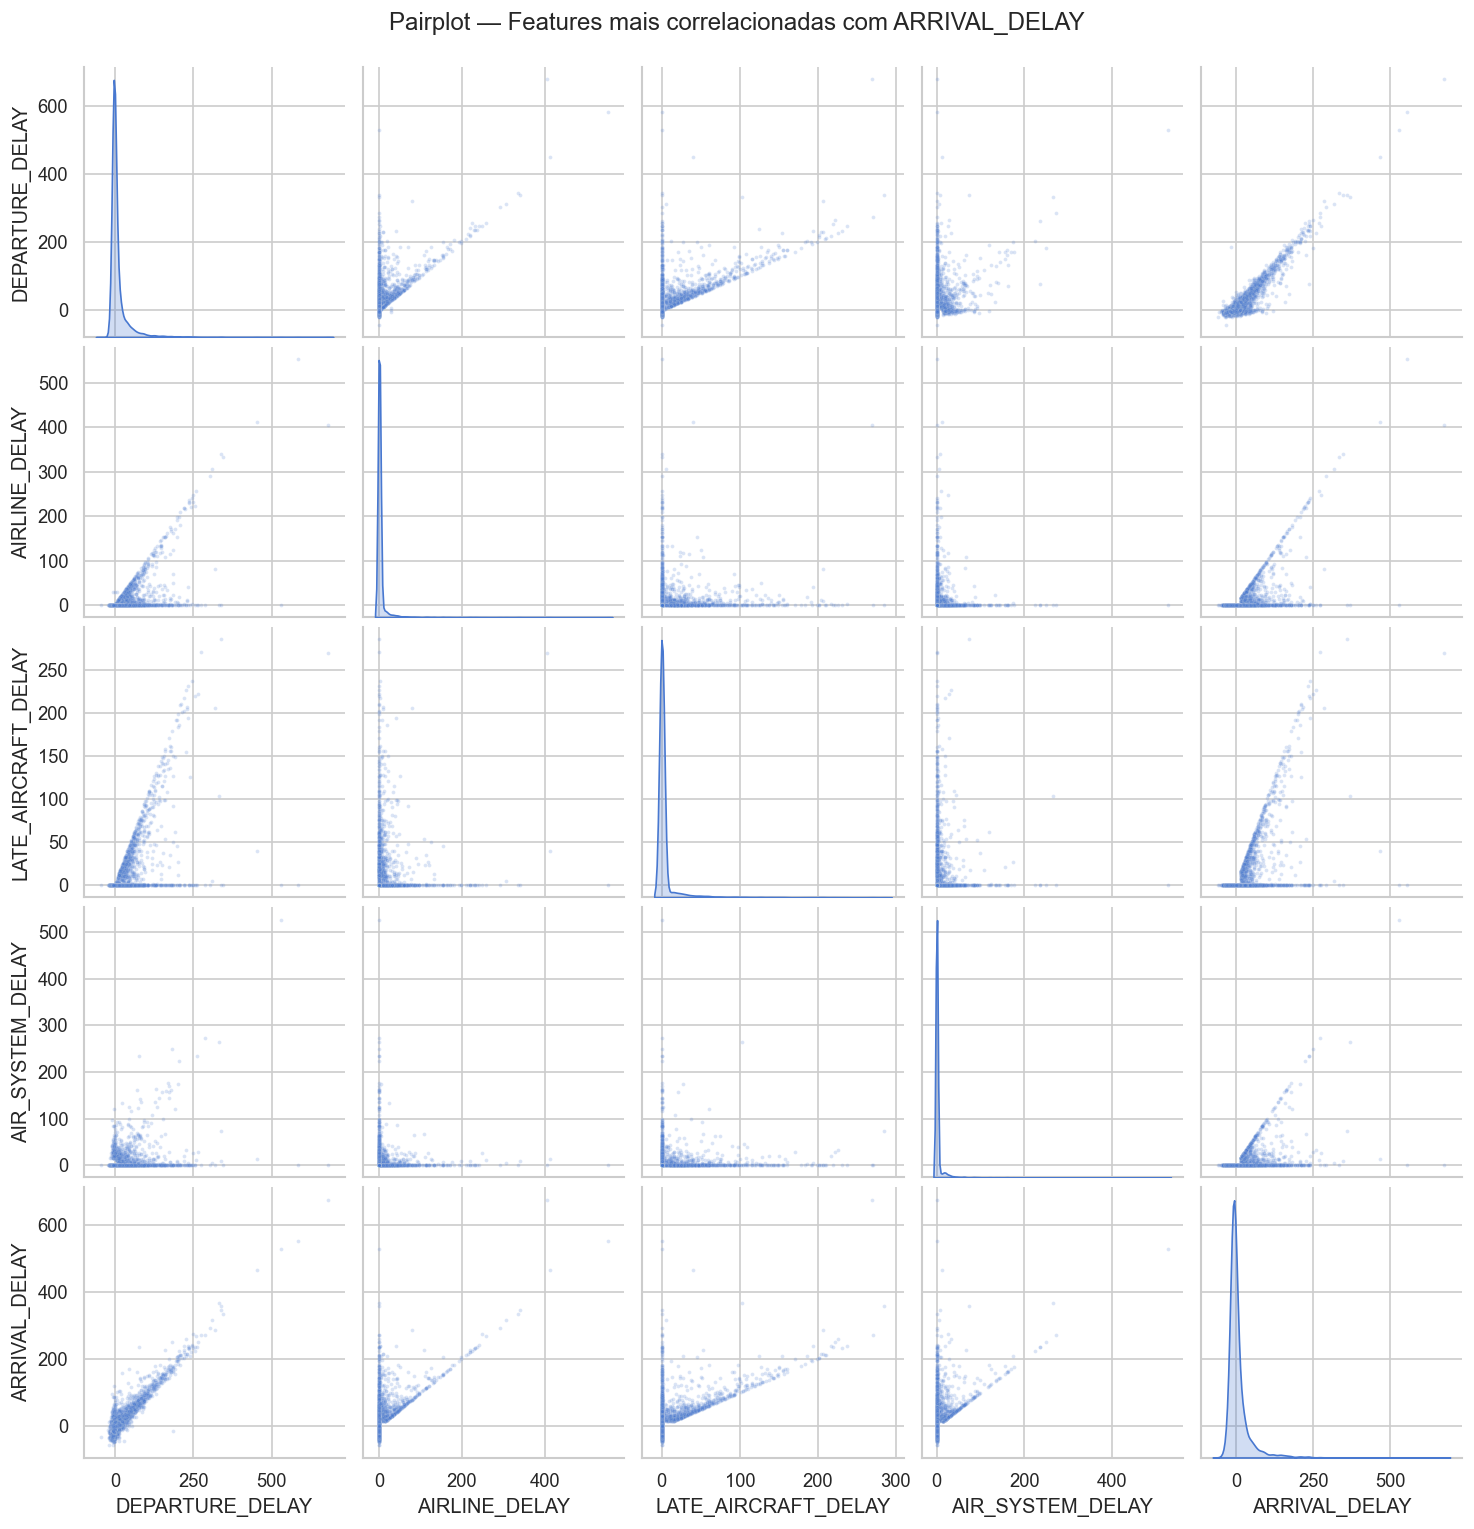

In [ ]:
# Scatter matrix: 4 features mais correlacionadas com ARRIVAL_DELAY
top4 = (
    corr["ARRIVAL_DELAY"].drop("ARRIVAL_DELAY").abs().nlargest(4).index.tolist()
)
sample_corr = flights_ok[top4 + ["ARRIVAL_DELAY"]].dropna().sample(8_000, random_state=42)

pplot = sns.pairplot(sample_corr, diag_kind="kde", plot_kws={"alpha": 0.2, "s": 5})
pplot.figure.suptitle("Pairplot — Features mais correlacionadas com ARRIVAL_DELAY", y=1.02)
plt.savefig(FIGS / "eda_23_pairplot.png")
plt.show()

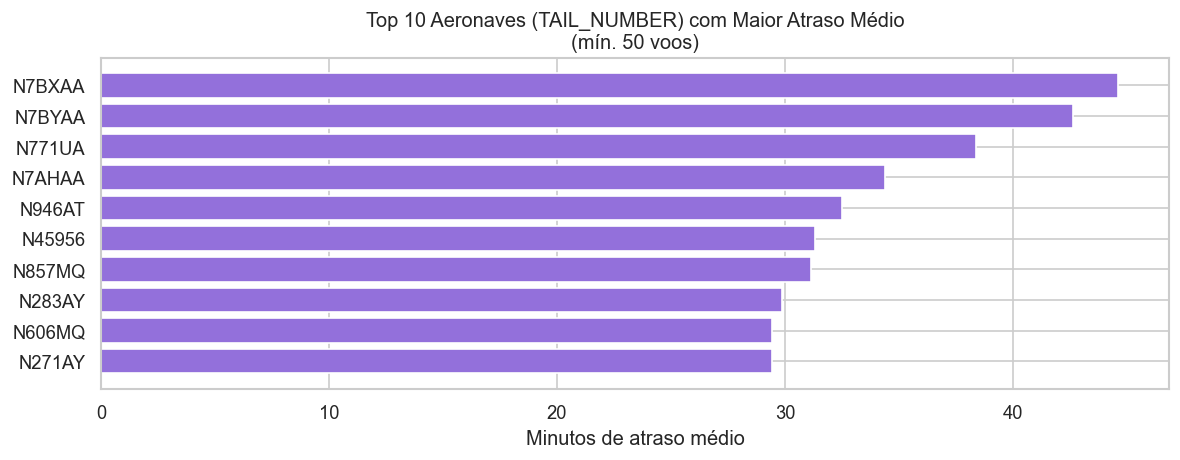

In [ ]:
# Aeronaves problemáticas — TAIL_NUMBER
tail_stats = (
    flights_ok.groupby("TAIL_NUMBER")
    .agg(avg_delay=("ARRIVAL_DELAY","mean"), count=("ARRIVAL_DELAY","count"))
    .query("count >= 50")
    .nlargest(10, "avg_delay")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(tail_stats["TAIL_NUMBER"].astype(str)[::-1],
        tail_stats["avg_delay"][::-1], color="mediumpurple")
ax.set_title("Top 10 Aeronaves (TAIL_NUMBER) com Maior Atraso Médio\n(mín. 50 voos)")
ax.set_xlabel("Minutos de atraso médio")
plt.tight_layout()
plt.savefig(FIGS / "eda_24_tail_number_delay.png")
plt.show()

 ---
 ## Seção 10 — Insights e Hipóteses para Modelagem

 ### Insight 1 — Efeito cascata ao longo do dia
 Voos nas primeiras horas (6–7h) têm atraso baixo (~2 min).
 Voos noturnos (21–23h) acumulam os atrasos do dia inteiro (>15 min médio).
 → **Hipótese:** `DEPARTURE_HOUR` será uma das features mais importantes nos modelos.

 ### Insight 2 — Sazonalidade: verão e inverno são os picos de atraso
 Junho/julho (alta demanda de verão) e dezembro (feriados/clima) concentram os maiores atrasos.
 → **Hipótese:** `MONTH` e uma feature `SEASON` terão poder preditivo relevante.

 ### Insight 3 — TAXI_OUT é proxy de congestionamento e preditor de atraso na partida
 Correlação positiva clara entre TAXI_OUT e DEPARTURE_DELAY.
 Aeroportos com TAXI_OUT > 20 min sistematicamente geram mais atrasos.
 → **Hipótese:** `TAXI_OUT` é feature forte, mas atenção ao **data leakage** em cenários
    de predição antes do voo (dado não disponível no momento do booking).

 ### Insight 4 — Companhias recuperam tempo de formas diferentes
 Algumas airlines chegam menos atrasadas do que partiram (TIME_RECOVERED positivo),
 sugerindo buffers de tempo no schedule. Outras propagam o atraso integralmente.
 → **Hipótese:** `AIRLINE` como variável categórica capturará este comportamento diferenciado.

 ### Insight 5 — Causa de atraso varia sistematicamente por companhia
 Airlines menores concentram LATE_AIRCRAFT_DELAY; maiores sofrem mais com AIR_SYSTEM_DELAY.
 → **Hipótese:** Colunas de causa de delay são altamente informativas, mas causam **data leakage**
    (só existem após o voo). Devem ser excluídas de modelos preditivos reais.

 ### Insight 6 — Voos curtos atrasam mais proporcionalmente
 Categoria "Curto (<500mi)" tem atraso médio maior; voos longos têm mais buffer temporal.
 → **Hipótese:** `DISTANCE_BUCKET` ou `DISTANCE` diretamente serão features relevantes.

 ### Insight 7 — Cancelamentos têm padrão sazonal e geográfico
 Pico em dezembro/janeiro (clima/feriados). Hubs grandes (ORD, ATL, DFW) lideram em volume.
 Clima + Sistema Aéreo respondem por ~70% das razões de cancelamento.
 → **Hipótese:** cancelamentos podem ser alvo de um modelo secundário (predição de cancelamento).

 ### Insight 8 — DEPARTURE_DELAY é o melhor preditor de ARRIVAL_DELAY (r ≈ 0.96)
 Quase toda a variância de ARRIVAL_DELAY é explicada pelo atraso na partida.
 → **Atenção crítica:** Para predição **antes** do voo, DEPARTURE_DELAY NÃO pode ser feature
    (leakage). O modelo deve funcionar com dados disponíveis no momento do booking.

 ### Insight 9 — Sexta-feira é o dia mais crítico da semana
 Taxa de atraso consistentemente mais alta às sextas, em quase todos os meses.
 → **Hipótese:** `IS_WEEKEND` e `DAY_OF_WEEK` são features importantes.

 ### Insight 10 — Companhia + Aeronave Atrasada respondem por 65% dos minutos de atraso
 Fatores operacionais internos dominam sobre clima (< 10% dos minutos totais).
 → **Hipótese:** melhorias operacionais das airlines têm maior impacto do que fatores climáticos.

In [ ]:
# Resumo final
print("\n=== Resumo Final da EDA ===")
total     = len(flights)
canceled  = (flights["CANCELLED"] == 1).sum()
atrasados = (flights_ok["ARRIVAL_DELAY"] > 15).sum()

print(f"Total de voos           : {total:>10,}")
print(f"Cancelados              : {canceled:>10,}  ({canceled/total*100:.2f}%)")
print(f"Voos completados        : {len(flights_ok):>10,}")
print(f"Atrasados >15 min       : {atrasados:>10,}  ({atrasados/len(flights_ok)*100:.2f}%)")
print(f"Mediana ARRIVAL_DELAY   : {flights_ok['ARRIVAL_DELAY'].median():>10.1f} min")
print(f"Média   ARRIVAL_DELAY   : {flights_ok['ARRIVAL_DELAY'].mean():>10.1f} min")
print(f"\nFiguras salvas em : {FIGS.resolve()}")
print(f"Total de figuras  : {len(list(FIGS.glob('eda_*.png')))}")


=== Resumo Final da EDA ===
Total de voos           :  5,819,079
Cancelados              :     89,884  (1.54%)
Voos completados        :  5,714,008
Atrasados >15 min       :  1,023,498  (17.91%)
Mediana ARRIVAL_DELAY   :       -5.0 min
Média   ARRIVAL_DELAY   :        4.4 min

Figuras salvas em : /Users/carpinterlouzada/repo/TechChallenger3/outputs/figures
Total de figuras  : 33


Restarted .venv (3.12.0) (Python 3.12.0)